<h3 style="font-size:17px; font-weight:bold;">Rețele Neuronale Convoluționale</h3>

<h5 style="font-size:14px;">

**Definiție:** Rețelele neuronale convoluționale (CNN - Convolutional Neural Networks) sunt modele de învățare profundă inspirate din funcționarea sistemului vizual uman, utilizate în special pentru procesarea imaginilor, recunoașterea obiectelor și analiza datelor cu structură spațială. Acestea folosesc operații de convoluție pentru a extrage automat caracteristici importante din date, fără a necesita selectarea manuală a acestora.  

**Tipuri de rețele neuronale convoluționale:**<br>
- **CNN simplă:** arhitectură de bază formată din straturi convoluționale și straturi complet conectate, utilizată pentru clasificări simple de imagini.<br>
- **LeNet:** una dintre primele arhitecturi CNN, utilizată pentru recunoașterea cifrelor scrise de mână.<br>
- **AlexNet:** rețea CNN profundă care a demonstrat eficiența deep learning în clasificarea imaginilor de dimensiuni mari.<br>
- **VGGNet:** arhitectură bazată pe utilizarea mai multor straturi convoluționale mici pentru extragerea caracteristicilor complexe.<br>
- **ResNet:** introduce conexiuni reziduale (skip connections) pentru antrenarea rețelelor foarte adânci.<br>
- **EfficientNet:** arhitectură optimizată pentru obținerea unui echilibru între precizie și eficiență computațională.<br>

**Elemente teoretice:**<br>
- **Strat convoluțional (Convolutional Layer):** aplică filtre (kernel-uri) peste datele de intrare pentru identificarea caracteristicilor precum margini, texturi și forme.<br>
- **Filtru / Kernel:** matrice de valori utilizată pentru extragerea caracteristicilor locale din imagine.<br>
- **Operația de convoluție:** proces matematic prin care filtrul este deplasat peste imagine pentru a genera hărți de caracteristici (feature maps).<br>
- **Feature Map:** rezultatul aplicării unui filtru convoluțional, reprezentând caracteristicile extrase din date.<br>
- **Pooling Layer:** reduce dimensiunea datelor păstrând informațiile importante (ex: Max Pooling, Average Pooling).<br>
- **Fully Connected Layer:** strat final care combină caracteristicile extrase și realizează clasificarea.<br>
- **Funcția de activare:** introduce neliniaritate în model (ex: ReLU, sigmoid, softmax).<br>
- **Backpropagation:** algoritm utilizat pentru ajustarea ponderilor rețelei pe baza erorii obținute.<br>
- **Dropout:** tehnică de regularizare care dezactivează aleator neuroni în timpul antrenării pentru reducerea overfitting-ului.<br>

**Presupuneri / caracteristici:**<br>
- **Extracție automată a caracteristicilor:** CNN-urile identifică automat elemente importante din imagini fără intervenție manuală.<br>
- **Partajarea parametrilor:** aceleași filtre sunt utilizate pe diferite regiuni ale imaginii, reducând numărul de parametri ai modelului.<br>
- **Detectarea relațiilor spațiale:** pot identifica poziția și relațiile dintre elementele din imagine.<br>
- **Necesită resurse computaționale ridicate:** antrenarea modelelor CNN poate necesita GPU și un volum mare de date.<br>
- **Generalizare:** capacitatea modelului de a recunoaște corect imagini sau date noi.<br>
- **Overfitting:** apare atunci când modelul memorează datele de antrenare și are performanțe slabe pe date necunoscute.<br>
- **Regularizare:** metode precum dropout, augmentarea datelor și normalizarea batch-urilor sunt utilizate pentru îmbunătățirea performanței.<br>
- **Normalizarea datelor:** imaginile și valorile de intrare sunt scalate pentru stabilizarea procesului de antrenare.<br><br>

</h5>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/validation",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

Found 19943 files belonging to 2 classes.


Found 2492 files belonging to 2 classes.
Found 2495 files belonging to 2 classes.


In [3]:
class_names = train_dataset.class_names
print(class_names)

['cats', 'dogs']


In [4]:
train_dataset = train_dataset.shuffle(1000)

In [5]:
for root, dirs, files in os.walk("../data"):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path).convert("RGB")
            img.save(path)      
            
        except:
            print("Deleted bad image:", path)
            os.remove(path)

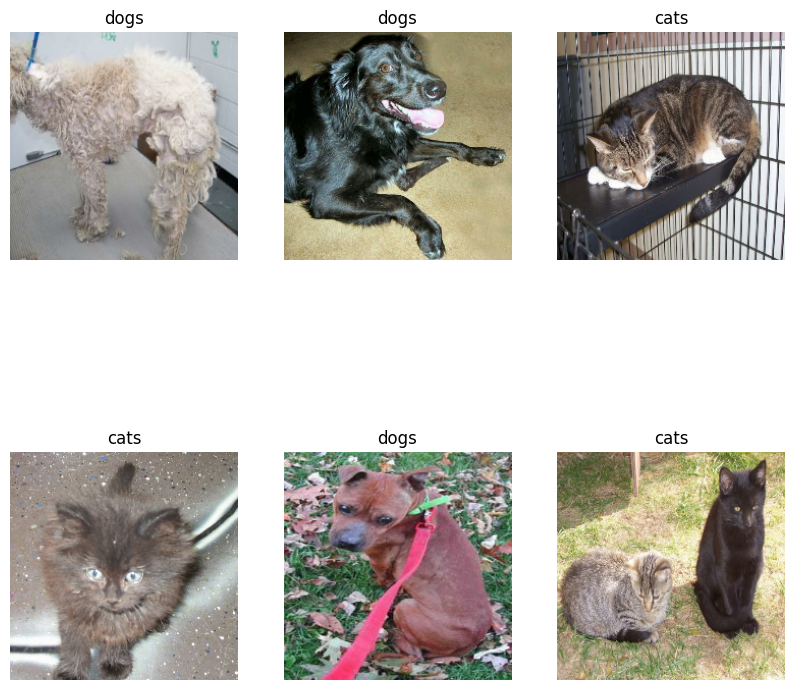

In [6]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [8]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalMaxPool2D # type: ignore
import tensorflow as tf

model = Sequential()

model.add(Input(shape=(224,224,3)))

model.add(data_augmentation)

model.add(Conv2D(32, (7,7), padding='same'))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (5,5)))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3,3)))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.2))

model.add(Conv2D(256, (3,3)))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3)))
model.add(tf.keras.layers.Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(GlobalMaxPool2D())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 108, 108, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,084,097 (4.14 MB)

 Trainable params: 1,082,625 (4.13 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    steps_per_epoch=10 
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 460s 13s/step - accuracy: 0.5281 - loss: 3.2073 - val_accuracy: 0.5004 - val_loss: 4.5579
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 108s 12s/step - accuracy: 0.5281 - loss: 1.9357 - val_accuracy: 0.5004 - val_loss: 9.3902
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 125s 14s/step - accuracy: 0.5000 - loss: 1.3172 - val_accuracy: 0.5004 - val_loss: 4.2310
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 131s 14s/step - accuracy: 0.5000 - loss: 1.2557 - val_accuracy: 0.4996 - val_loss: 4.4417
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 123s 13s/step - accuracy: 0.4906 - loss: 1.4538 - val_accuracy: 0.5004 - val_loss: 4.0007


In [11]:
loss, acc = model.evaluate(test_dataset)
print("Accuracy:", acc)

78/78 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5002 - loss: 4.0168
Accuracy: 0.5002003908157349


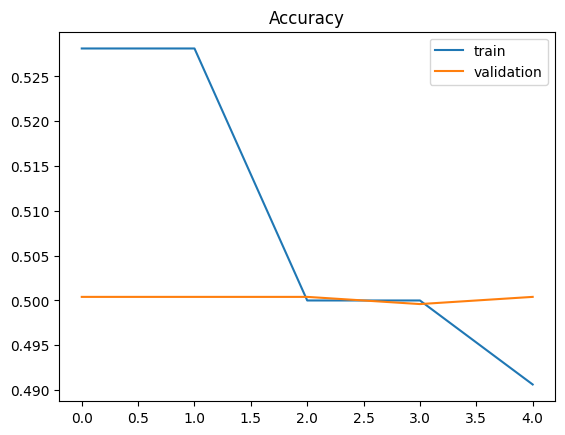

In [12]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy")
plt.show()

In [13]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_resnet = tf.keras.Sequential([
    base_model,
    GlobalMaxPool2D(),
    Dense(1, activation='sigmoid')
])

model_resnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_resnet = model_resnet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    steps_per_epoch=10,
    validation_steps=10
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 310s 5s/step - accuracy: 0.7281 - loss: 1.6892 - val_accuracy: 0.8156 - val_loss: 0.9930
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8844 - loss: 0.4538 - val_accuracy: 0.8750 - val_loss: 0.6895
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8719 - loss: 0.6364 - val_accuracy: 0.8969 - val_loss: 0.5508
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.8906 - loss: 0.4324 - val_accuracy: 0.9219 - val_loss: 0.4166
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.9219 - loss: 0.3514 - val_accuracy: 0.9500 - val_loss: 0.1861
